# 분류 Classification

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72119 entries, 0 to 72118
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   v         72119 non-null  float64
 1   a         72119 non-null  float64
 2   sin       72119 non-null  float64
 3   FC_msec   72119 non-null  float64
 4   FC_Label  72119 non-null  float64
dtypes: float64(5)
memory usage: 2.8 MB
None
              v         a       sin   FC_msec  FC_Label
count  72119.00  72119.00  72119.00  72119.00  72119.00
mean       0.33     -0.00     -0.00      9.00      1.92
std        0.25      0.25      0.22      7.70      1.30
min        0.00     -1.99     -1.00      0.00      0.00
25%        0.08     -0.07     -0.05      2.69      1.00
50%        0.33      0.00      0.00      6.66      2.00
75%        0.50      0.09      0.05     13.31      3.00
max        1.00      1.70      1.00     46.85      6.00
FC_Label
1.0    28740
2.0    17062
3.0    10346
4.0     6446
0.0     5

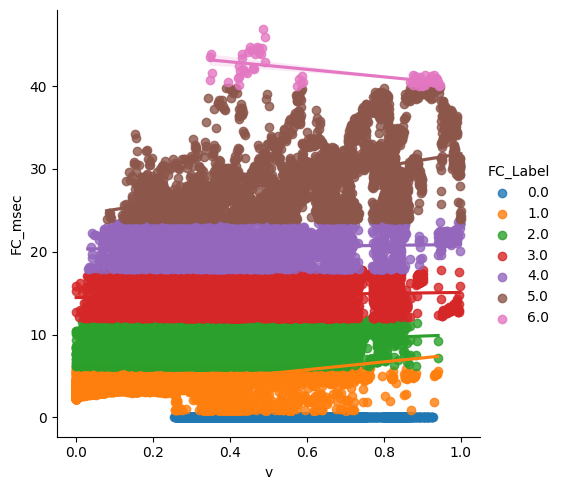

(43271, 3) (14424, 3) (14424, 3)
(43271,) (14424,) (14424,)


In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import keras

# Feature : v(speed) = v / v_max     a(acceleration) = a * 5     sin(gradient)
# Target : FC_Label(Fuel Consumption) = 0 ~ 6

FC = pd.read_csv('FC_new.csv')

print(FC.info())  
print(FC.describe().round(2))
print(FC['FC_Label'].value_counts())

sns.lmplot(data=FC, x='v', y='FC_msec', hue='FC_Label')
plt.show()

feature = FC[['v','a','sin']].to_numpy()
target = FC['FC_Label'].to_numpy()
train_input, test_input, train_target, test_target = train_test_split(feature, target, test_size=0.4, random_state=42) 
val_input, test_input, val_target, test_target = train_test_split(test_input, test_target, test_size=0.5, random_state=42) 

print(train_input.shape, val_input.shape, test_input.shape)   
print(train_target.shape, val_target.shape, test_target.shape)

In [10]:
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(7, activation='softmax'))

Epoch 1/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 2s 585us/step - accuracy: 0.5903 - loss: 1.0494 - val_accuracy: 0.7062 - val_loss: 0.7003
Epoch 2/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - accuracy: 0.6880 - loss: 0.7457 - val_accuracy: 0.7191 - val_loss: 0.6605
Epoch 3/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - accuracy: 0.7044 - loss: 0.7061 - val_accuracy: 0.7255 - val_loss: 0.6562
Epoch 4/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step - accuracy: 0.7085 - loss: 0.6961 - val_accuracy: 0.7280 - val_loss: 0.6454
Epoch 5/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 544us/step - accuracy: 0.7134 - loss: 0.6837 - val_accuracy: 0.7277 - val_loss: 0.6425
Epoch 6/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.7130 - loss: 0.6926 - val_accuracy: 0.7207 - val_loss: 0.6575
Epoch 7/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 538us/step - accuracy: 0.7158 - loss: 0.6824 - val_accuracy: 0.7289 - val_loss: 0.6362
Epoch 8/10
1353/1353 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.7193 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           707 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,923 (249.70 KB)

 Trainable params: 21,307 (83.23 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 42,616 (166.47 KB)

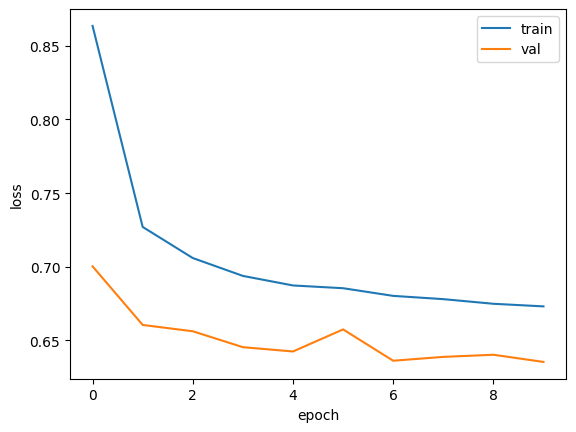

In [11]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_input, train_target, epochs=10, validation_data=(val_input, val_target))
model.summary()
model.save('FC_class.keras')
plt.plot(history.history['loss']) 
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step
Confusion Matrix:
 [[ 894  114   86    3    1    0    0]
 [ 412 4881  485   21    4    0    0]
 [ 177  383 2309  497   22    3    0]
 [   9   10  448 1382  222   21    0]
 [   2    3   45  434  651  174    0]
 [   3    0    7   29  154  525    0]
 [   0    0    1    0    2   10    0]]
Accuracy: 0.738
Precision: [0.597 0.905 0.683 0.584 0.616 0.716 0.   ]
Recall (Sensitivity): [0.814 0.841 0.681 0.661 0.497 0.731 0.   ]
F1 Score: [0.689 0.872 0.682 0.62  0.551 0.724 0.   ]


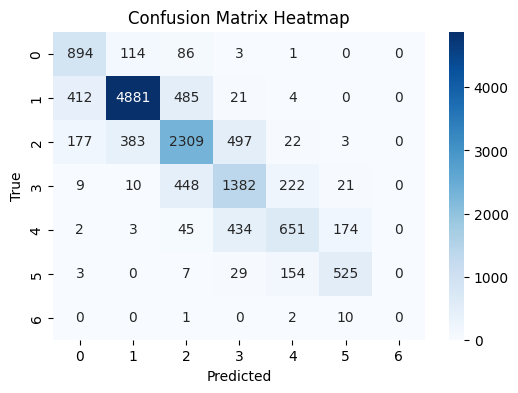

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
test_pred = np.argmax(model.predict(test_input), axis=1)
cm = confusion_matrix(test_target, test_pred)
accuracy = round(accuracy_score(test_target, test_pred), 3)
precision = precision_score(test_target, test_pred, average=None, zero_division=0).round(3)
recall = recall_score(test_target, test_pred, average=None, zero_division=0).round(3)
f1 = f1_score(test_target, test_pred, average=None, zero_division=0).round(3)

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall (Sensitivity): {recall}")
print(f"F1 Score: {f1}")

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()